In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
file_list = [
    "respiratory_importance.tsv",
    "renal_importance.tsv",
    "liver_importance.tsv",
    "coag_importance.tsv",
    "cardio_importance.tsv",
    "cns_importance.tsv",
]

In [11]:
results = []

for file_name in file_list:
    df = pd.read_csv(file_name, sep="\t").head(10)
    results.append(df)

results = pd.concat(results)

In [15]:
results

,feature,importance 0,importance 1,importance 2,Mean Importance,Panel
0,EPCR,0.865473,0.979759,0.735173,0.860135,Respiratory
1,PSPB,0.824897,0.556318,0.686727,0.689314,Respiratory
2,PCSK9,0.516378,0.755275,0.688138,0.653264,Respiratory
3,RNAS1,0.323548,0.779730,0.732302,0.611860,Respiratory
4,APOL1,0.852660,0.463343,0.506179,0.607394,Respiratory
5,ADIPO,0.653874,0.605853,0.543303,0.601010,Respiratory
6,ENOA,0.681846,0.614133,0.476331,0.590770,Respiratory
7,COMP,0.369388,0.676967,0.622343,0.556233,Respiratory
8,PCYOX,0.616250,0.828629,0.222601,0.555827,Respiratory
9,A1AG2,0.610064,0.582873,0.447194,0.546710,Respiratory


In [12]:
import colorcet as cc

In [13]:
colormap = cc.glasbey_cool

In [17]:
cmap = sns.color_palette(colormap, n_colors=6)

In [18]:
organ_dysfunctions = results['Panel'].unique()

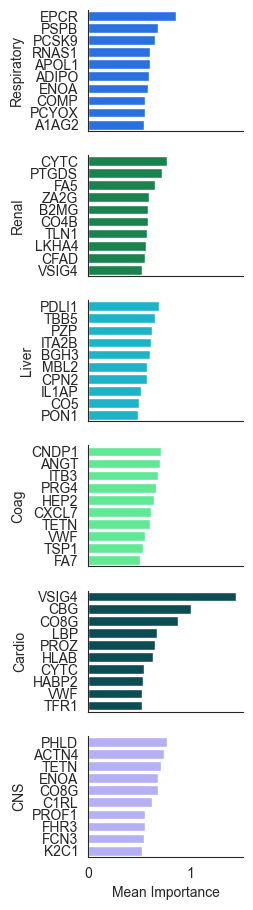

In [25]:
sns.set_style("white")

fig, axs = plt.subplots(
    nrows=6,
    ncols=1,
    sharex=True,
)

for i, organ_dysfunction in enumerate(organ_dysfunctions):

    subset = results[results["Panel"] == organ_dysfunction]

    sns.barplot(
        data=subset,
        x="Mean Importance",
        y="feature",
        ax=axs[i],
        color=cmap[i],
    )

    axs[i].set_ylabel(organ_dysfunction)

sns.despine()
fig.set_size_inches(
    (2, 11)
)

fig.savefig(
    "feature_importance.pdf",
    bbox_inches="tight",
    dpi=300,
)